📦 통합 데이터 로드 완료: 총 23076건


/var/folders/r4/hxbkwz9j2rv_c2zl6mnj94ww0000gn/T/ipykernel_39957/3014329091.py:36: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


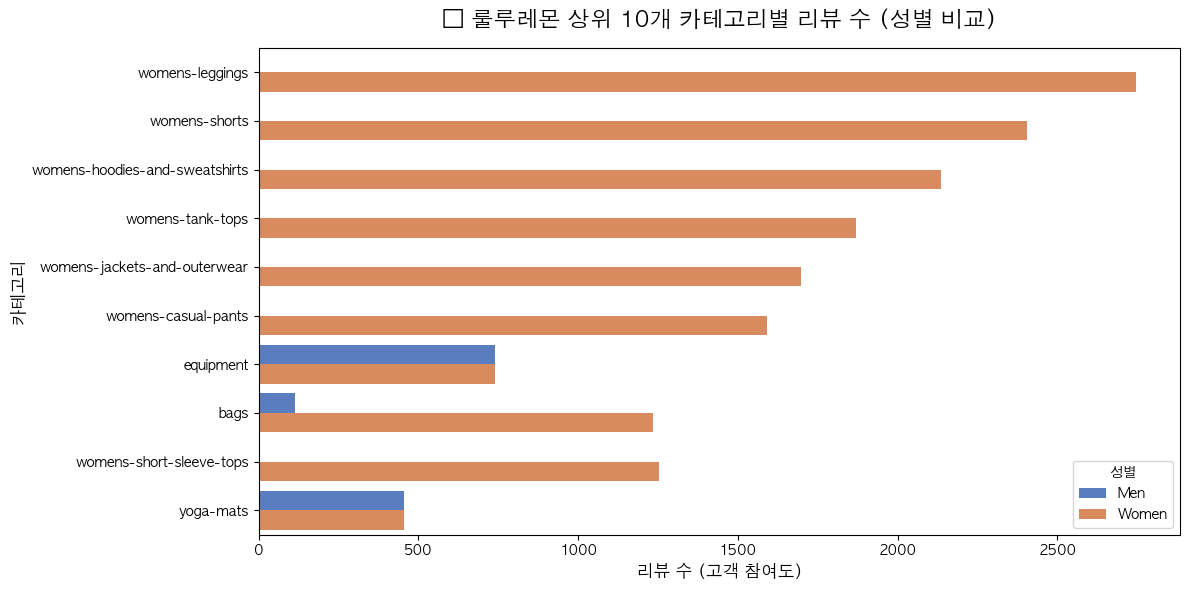

/var/folders/r4/hxbkwz9j2rv_c2zl6mnj94ww0000gn/T/ipykernel_39957/3014329091.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender_label', y='min_price', width=0.5, palette='pastel')
/var/folders/r4/hxbkwz9j2rv_c2zl6mnj94ww0000gn/T/ipykernel_39957/3014329091.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}원'.format(x) for x in current_values])
/var/folders/r4/hxbkwz9j2rv_c2zl6mnj94ww0000gn/T/ipykernel_39957/3014329091.py:53: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font

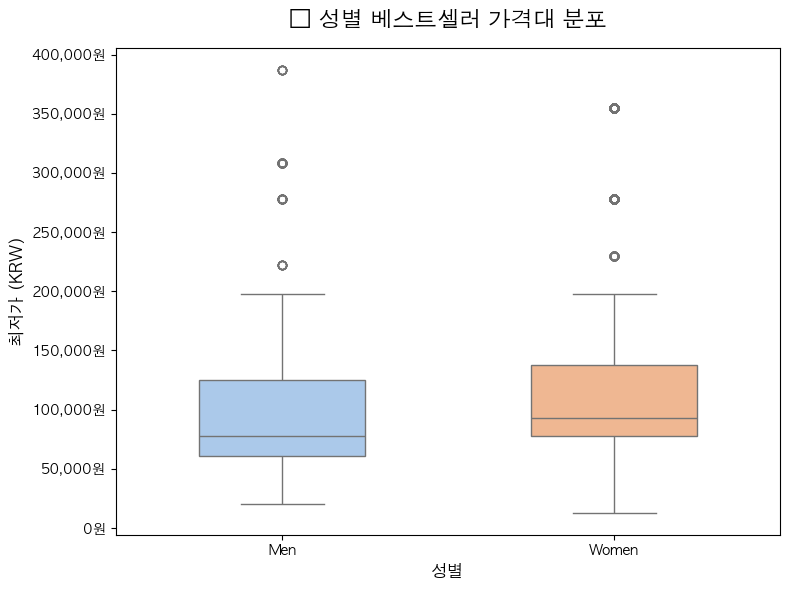

/var/folders/r4/hxbkwz9j2rv_c2zl6mnj94ww0000gn/T/ipykernel_39957/3014329091.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(['{:,.0f}원'.format(x) for x in current_values])
/var/folders/r4/hxbkwz9j2rv_c2zl6mnj94ww0000gn/T/ipykernel_39957/3014329091.py:95: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


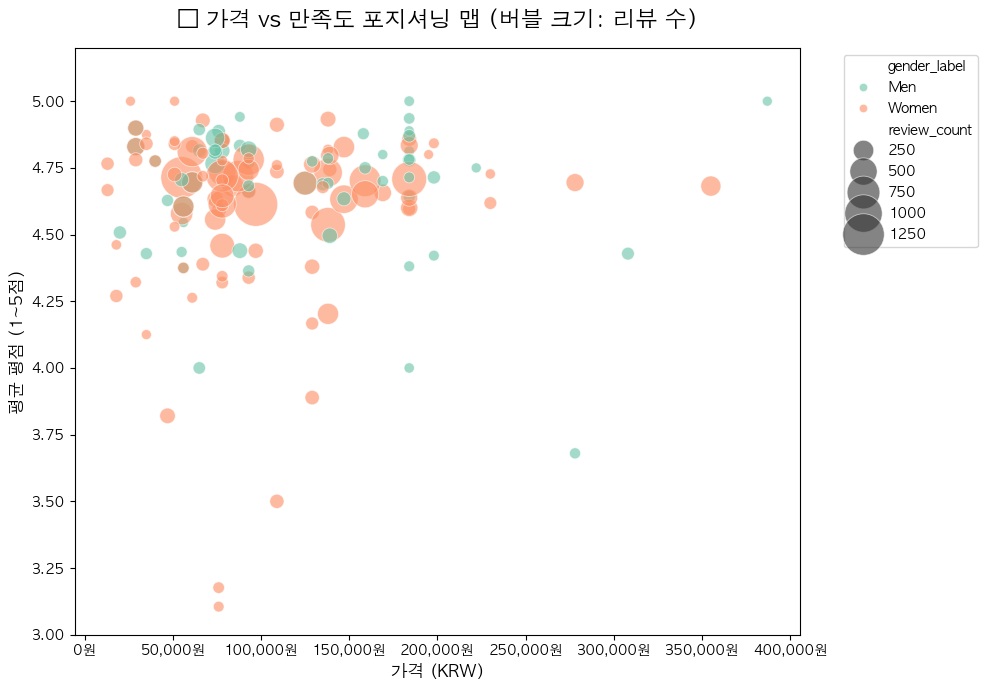

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🍎 맥북 환경 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 로드
# ==========================================
base_path = "/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/data/"
filename = "lululemon_bestseller_merged.csv"

df = pd.read_csv(base_path + filename)
print(f"📦 통합 데이터 로드 완료: 총 {len(df)}건")


# ==========================================
# 2. 카테고리별 고객 참여도 (리뷰 수) 분석
# ==========================================
plt.figure(figsize=(12, 6))
# 상위 10개 카테고리만 추출
top_categories = df['category'].value_counts().nlargest(10).index
sns.countplot(
    data=df[df['category'].isin(top_categories)], 
    y='category', 
    hue='gender_label', 
    order=top_categories, 
    palette='muted'
)
plt.title('🏆 룰루레몬 상위 10개 카테고리별 리뷰 수 (성별 비교)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('리뷰 수 (고객 참여도)', fontsize=12)
plt.ylabel('카테고리', fontsize=12)
plt.legend(title='성별')
plt.tight_layout()
plt.show()


# ==========================================
# 3. 성별에 따른 가격대 분포 (Boxplot)
# ==========================================
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='gender_label', y='min_price', width=0.5, palette='pastel')
plt.title('💰 성별 베스트셀러 가격대 분포', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('성별', fontsize=12)
plt.ylabel('최저가 (KRW)', fontsize=12)

# Y축 가격 단위를 보기 좋게 (천원 단위) 변경
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}원'.format(x) for x in current_values])

plt.tight_layout()
plt.show()


# ==========================================
# 4. 가격과 평점의 상관관계 (포지셔닝 맵)
# ==========================================
# 상품별로 평균 평점, 최저가, 리뷰 수를 집계합니다.
product_stats = df.groupby(['product_name', 'gender_label']).agg(
    avg_rating=('rating', 'mean'),
    price=('min_price', 'min'),
    review_count=('rating', 'count')
).reset_index()

# 리뷰가 너무 적은 상품은 노이즈가 될 수 있으므로 제외 (예: 리뷰 3개 이상만)
product_stats = product_stats[product_stats['review_count'] >= 3]

plt.figure(figsize=(10, 7))
# 리뷰 수(review_count)를 버블의 크기(size)로 설정
sns.scatterplot(
    data=product_stats, 
    x='price', 
    y='avg_rating', 
    hue='gender_label',
    size='review_count', 
    sizes=(50, 1000), # 버블 크기 최소/최대
    alpha=0.6,
    palette='Set2'
)
plt.title('🎯 가격 vs 만족도 포지셔닝 맵 (버블 크기: 리뷰 수)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('가격 (KRW)', fontsize=12)
plt.ylabel('평균 평점 (1~5점)', fontsize=12)

# Y축 한계 설정 (평점이 주로 3~5점 사이에 몰려있으므로)
plt.ylim(3.0, 5.2)

# X축 가격 포맷팅
current_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.0f}원'.format(x) for x in current_values])

# 범례가 그래프를 가리지 않도록 밖으로 이동
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/r4/hxbkwz9j2rv_c2zl6mnj94ww0000gn/T/ipykernel_39957/2554935416.py:23: UserWarning: Glyph 128105 (\N{WOMAN}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128105 (\N{WOMAN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


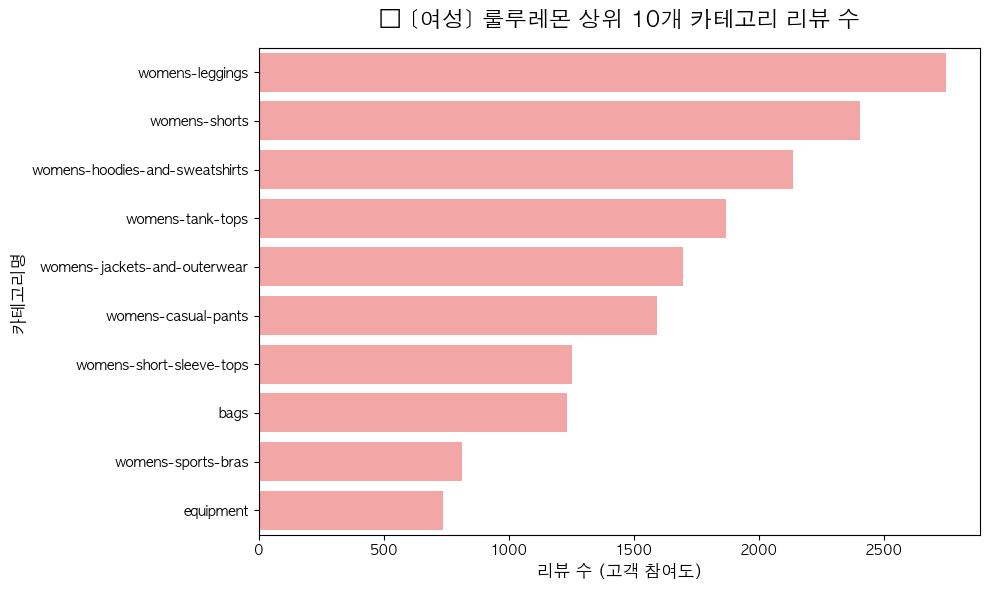

/var/folders/r4/hxbkwz9j2rv_c2zl6mnj94ww0000gn/T/ipykernel_39957/2554935416.py:40: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


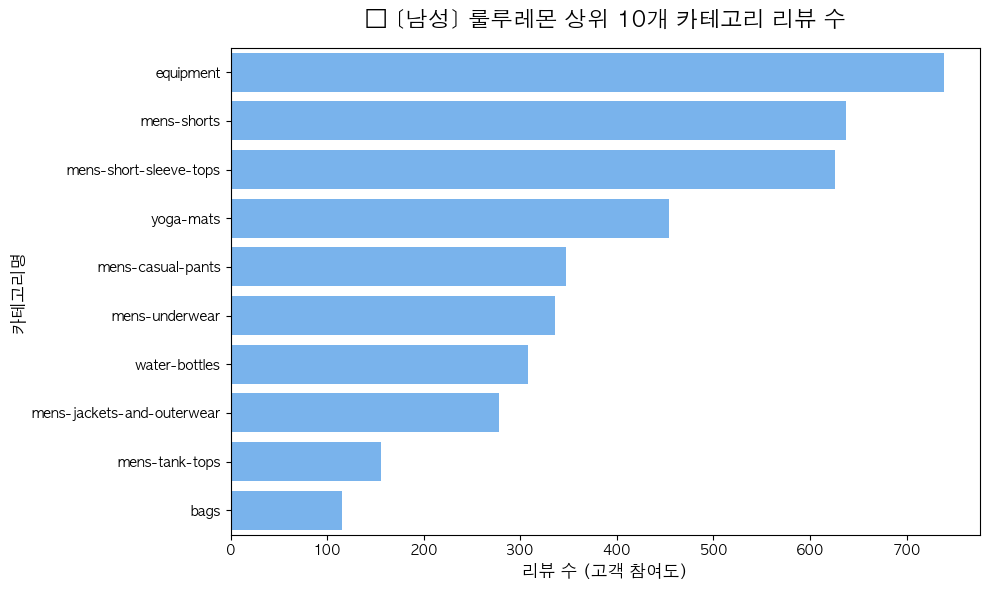

In [2]:
# 여성, 남성 데이터 분리
df_women = df[df['gender_label'] == 'Women']
df_men = df[df['gender_label'] == 'Men']

# 각 성별별 상위 10개 카테고리 추출
top_w_cats = df_women['category'].value_counts().head(10).index
top_m_cats = df_men['category'].value_counts().head(10).index


# ==========================================
# 2. 👩 여성 상위 10개 카테고리 그래프
# ==========================================
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_women[df_women['category'].isin(top_w_cats)], 
    y='category', 
    order=top_w_cats, 
    color='#ff9999' # 여성 직관적 컬러
)
plt.title('👩 [여성] 룰루레몬 상위 10개 카테고리 리뷰 수', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('리뷰 수 (고객 참여도)', fontsize=12)
plt.ylabel('카테고리명', fontsize=12)
plt.tight_layout()
plt.show()


# ==========================================
# 3. 👨 남성 상위 10개 카테고리 그래프
# ==========================================
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_men[df_men['category'].isin(top_m_cats)], 
    y='category', 
    order=top_m_cats, 
    color='#66b3ff' # 남성 직관적 컬러
)
plt.title('👨 [남성] 룰루레몬 상위 10개 카테고리 리뷰 수', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('리뷰 수 (고객 참여도)', fontsize=12)
plt.ylabel('카테고리명', fontsize=12)
plt.tight_layout()
plt.show()

## 텍스트 분석

⏳ 리뷰 텍스트 TPO 및 속성 라벨링 진행 중...

[📊 TPO별 시장 수요 및 가격대 요약]


,TPO_Label,avg_price,avg_rating,review_count
3,일상/출근(원마일웨어),127851.562500,4.856445,1024
1,러닝/마라톤,86051.948052,4.879221,770
2,요가/필라테스,103789.709172,4.908277,447
4,헬스/크로스핏,101937.931034,4.800000,145
0,골프/테니스,114829.268293,4.951220,41


/var/folders/r4/hxbkwz9j2rv_c2zl6mnj94ww0000gn/T/ipykernel_39957/614380544.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(['{:,.0f}원'.format(x) for x in current_values])
/var/folders/r4/hxbkwz9j2rv_c2zl6mnj94ww0000gn/T/ipykernel_39957/614380544.py:111: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


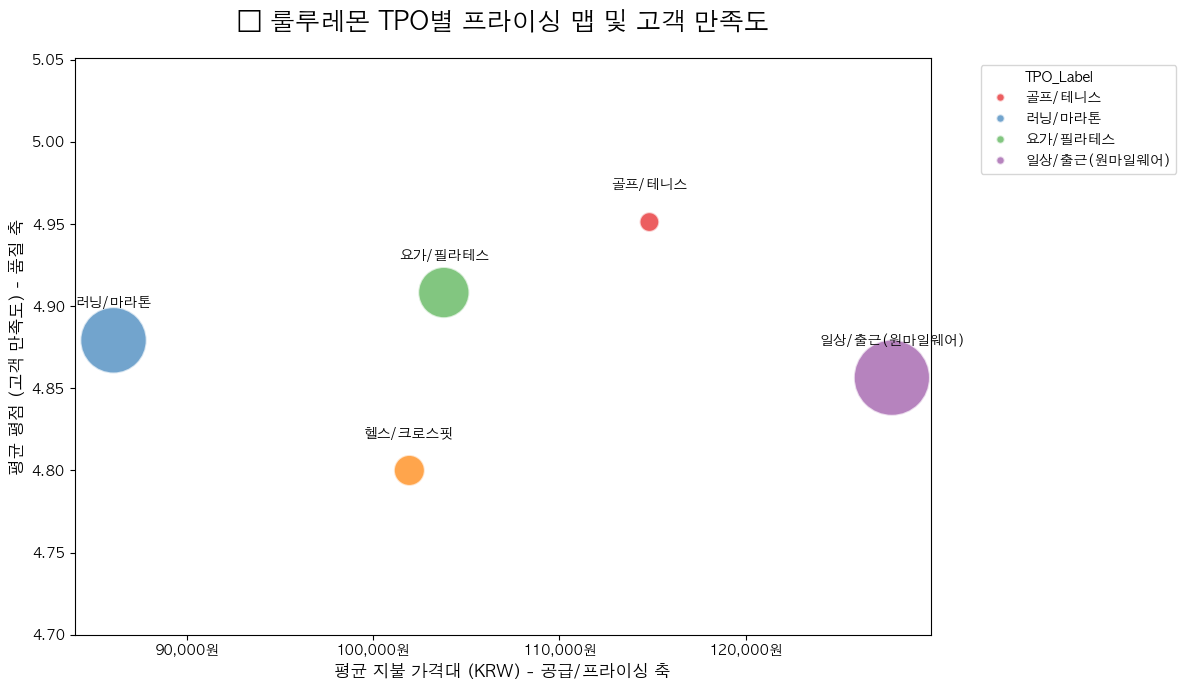


[🚨 불만족(3점 이하) 리뷰의 주요 언급 속성 (Pain Point)]


Attribute_Label
핏/사이즈     93
소재/기능성    62
가격/가성비     2
Name: count, dtype: int64

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kiwipiepy import Kiwi

# 🍎 맥북 환경 폰트 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 텍스트 결측치 처리
# ==========================================
df = df.dropna(subset=['review_text']).copy()


# ==========================================
# 2. Taxonomy (분류 체계) 사전 구축
# ==========================================
# 💡 TPO(상황) 및 속성 키워드 사전을 정의합니다.
tpo_dict = {
    '러닝/마라톤': ['러닝', '런닝', '마라톤', '뛰다', '조깅', '달리기'],
    '요가/필라테스': ['요가', '필라테스', '스트레칭', '매트운동'],
    '헬스/크로스핏': ['헬스', '웨이트', '크로스핏', 'PT', '피티', '짐'],
    '일상/출근(원마일웨어)': ['일상', '출근', '회사', '평상시', '데일리', '집', '외출', '여행', '비행기'],
    '골프/테니스': ['골프', '라운딩', '테니스', '라켓']
}

attribute_dict = {
    '소재/기능성': ['소재', '재질', '땀', '흡수', '통풍', '시원', '따뜻', '신축성', '보풀', '비침'],
    '핏/사이즈': ['핏', '사이즈', '길이', '수선', '허리', '기장', '품'],
    '가격/가성비': ['가격', '비싸다', '저렴', '가성비', '돈', '할인']
}

# ==========================================
# 3. Step 3: 텍스트 라벨링 (Rule-based ABSA MVP)
# ==========================================
kiwi = Kiwi()

def classify_text(text, target_dict):
    """텍스트 내에 사전에 정의된 키워드가 있으면 해당 카테고리를 반환합니다."""
    if not isinstance(text, str): return '기타/미언급'
    
    # 텍스트 형태소 분석 (명사, 동사, 형용사 추출)
    tokens = [t.form for t in kiwi.tokenize(text) if t.tag in ['NNG', 'NNP', 'VV', 'VA']]
    
    for category, keywords in target_dict.items():
        if any(keyword in tokens or keyword in text for keyword in keywords):
            return category
    return '기타/미언급'

print("⏳ 리뷰 텍스트 TPO 및 속성 라벨링 진행 중...")
df['TPO_Label'] = df['review_text'].apply(lambda x: classify_text(x, tpo_dict))
df['Attribute_Label'] = df['review_text'].apply(lambda x: classify_text(x, attribute_dict))


# ==========================================
# 4. Step 4: TPO별 프라이싱 맵 & 갭 분석 시각화
# ==========================================
# '기타/미언급'을 제외한 유의미한 TPO 데이터만 추출
df_tpo = df[df['TPO_Label'] != '기타/미언급'].copy()

# TPO별 평균 가격, 평균 평점, 리뷰 수 집계
tpo_summary = df_tpo.groupby('TPO_Label').agg(
    avg_price=('min_price', 'mean'),
    avg_rating=('rating', 'mean'),
    review_count=('rating', 'count')
).reset_index()

print("\n[📊 TPO별 시장 수요 및 가격대 요약]")
display(tpo_summary.sort_values(by='review_count', ascending=False))

# 📈 프라이싱 맵 시각화 (Bubble Chart)
plt.figure(figsize=(12, 7))

# 버블 차트: X=평균 가격, Y=만족도, 버블 크기=수요량(리뷰 수)
scatter = sns.scatterplot(
    data=tpo_summary, 
    x='avg_price', 
    y='avg_rating', 
    hue='TPO_Label', 
    size='review_count', 
    sizes=(200, 3000), 
    alpha=0.7, 
    palette='Set1'
)

plt.title('🎯 룰루레몬 TPO별 프라이싱 맵 및 고객 만족도', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('평균 지불 가격대 (KRW) - 공급/프라이싱 축', fontsize=12)
plt.ylabel('평균 평점 (고객 만족도) - 품질 축', fontsize=12)

# 각 버블 옆에 TPO 이름 표기
for i in range(tpo_summary.shape[0]):
    plt.text(
        tpo_summary['avg_price'].iloc[i], 
        tpo_summary['avg_rating'].iloc[i] + 0.02, 
        tpo_summary['TPO_Label'].iloc[i], 
        horizontalalignment='center', 
        size='medium', color='black', weight='semibold'
    )

# 축 포맷팅
current_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.0f}원'.format(x) for x in current_values])
plt.ylim(tpo_summary['avg_rating'].min() - 0.1, tpo_summary['avg_rating'].max() + 0.1)

# 범례 정리 (크기 범례 제거)
h, l = scatter.get_legend_handles_labels()
plt.legend(h[:len(tpo_dict)], l[:len(tpo_dict)], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 5. 속성(Attribute)에 따른 불만족 원인 파악
df_neg = df[(df['rating'] <= 3) & (df['Attribute_Label'] != '기타/미언급')]
neg_attr_counts = df_neg['Attribute_Label'].value_counts()

print("\n[🚨 불만족(3점 이하) 리뷰의 주요 언급 속성 (Pain Point)]")
display(neg_attr_counts)

## BERTopic

In [4]:
import pandas as pd
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
import matplotlib.pyplot as plt

# 🍎 맥북 폰트 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 준비
# ==========================================
base_path = "/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/data/"
df = pd.read_csv(base_path + "lululemon_bestseller_merged.csv")

# 결측치 제거 및 길이가 너무 짧은 리뷰(노이즈) 제외
df = df.dropna(subset=['review_text'])
df = df[df['review_text'].str.len() > 10].reset_index(drop=True)
docs = df['review_text'].tolist()

print(f"📦 분석할 리뷰 데이터: 총 {len(docs)}건")

# ==========================================
# 2. Kiwi 커스텀 토크나이저 (c-TF-IDF 용)
# ==========================================
kiwi = Kiwi()
kiwi.add_user_word('룰루레몬', 'NNP')
kiwi.add_user_word('얼라인', 'NNP')

# 형태소 분석기 함수 정의 (명사, 동사, 형용사만 추출)
def kiwi_tokenize(text):
    tokens = kiwi.tokenize(text)
    # NNG(일반명사), NNP(고유명사), VV(동사), VA(형용사)
    result = []
    for t in tokens:
        if t.tag in ['NNG', 'NNP', 'VV', 'VA'] and len(t.form) > 1:
            word = t.form
            if t.tag in ['VV', 'VA']: # 동사/형용사는 기본형으로 변환
                word += '다'
            result.append(word)
    return result

# CountVectorizer에 Kiwi 적용
vectorizer_model = CountVectorizer(tokenizer=kiwi_tokenize, max_df=0.85, min_df=3)


# ==========================================
# 3. BERTopic 파이프라인 구성 및 모델 학습
# ==========================================
print("⏳ 1/4 한국어 텍스트 임베딩 중... (SentenceTransformer)")
# 한국어 성능이 우수한 사전학습 모델 사용
embedding_model = SentenceTransformer('jhgan/ko-sroberta-multitask')

print("⏳ 2/4 차원 축소 중... (UMAP)")
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

print("⏳ 3/4 밀도 기반 군집화 중... (HDBSCAN)")
hdbscan_model = HDBSCAN(min_cluster_size=10, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

print("⏳ 4/4 토픽 모델링 및 키워드 추출 중... (BERTopic)")
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10, # 토픽당 추출할 키워드 수
    language="multilingual"
)

# 모델 학습 (Fit)
topics, probs = topic_model.fit_transform(docs)
print("✅ BERTopic 학습 완료!")


# ==========================================
# 4. 분석 결과 확인 및 시각화
# ==========================================
# 도출된 전체 토픽 정보 요약 (Topic -1은 분류되지 않은 노이즈/Outlier 입니다)
topic_info = topic_model.get_topic_info()
print("\n[📊 도출된 핵심 토픽 Top 10]")
display(topic_info.head(11)) # -1번 토픽을 포함하므로 11개 출력

# 📈 [시각화 1] 토픽별 핵심 키워드 바 차트 (공유해주신 자료의 핵심 기능!)
fig_barchart = topic_model.visualize_barchart(top_n_topics=8, n_words=8, title="주요 토픽별 핵심 키워드")
fig_barchart.show()

# 📈 [시각화 2] 토픽 간 거리 및 군집화 지도 (Intertopic Distance Map)
fig_intertopic = topic_model.visualize_topics(title="룰루레몬 리뷰 토픽 군집 지도")
fig_intertopic.show()

/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📦 분석할 리뷰 데이터: 총 23066건
⏳ 1/4 한국어 텍스트 임베딩 중... (SentenceTransformer)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 56149.78it/s]
RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⏳ 2/4 차원 축소 중... (UMAP)
⏳ 3/4 밀도 기반 군집화 중... (HDBSCAN)
⏳ 4/4 토픽 모델링 및 키워드 추출 중... (BERTopic)
✅ BERTopic 학습 완료!

[📊 도출된 핵심 토픽 Top 10]


,Topic,Count,Name,Representation,Representative_Docs
0,-1,12798,-1_사이즈_운동_편하다_구매,"[사이즈, 운동, 편하다, 구매, 소재, 느낌, 제품, 보이다, 색상, 편안]",[룰루레몬 페이스브레이커 7인치 쇼츠를 착용하고 러닝을 해보았습니다 완벽한 디자인과...
1,0,419,0____,"[, , , , , , , , , ]",[[This review was collected as part of a promo...
2,1,322,1____,"[, , , , , , , , , ]",[Almost wear it every day since I bought it! ...
3,2,306,2____,"[, , , , , , , , , ]",[[This review was collected as part of a promo...
4,3,301,3_가방_수납_여행_공간,"[가방, 수납, 여행, 공간, 들어가다, 다니다, 수납공간, 물건, 물통, 크로스]","[평소엔 운동용 가방,\n그리고 여행용 가방으로 구매했는데 수납넉넉하고 내부주머니도..."
5,4,291,4_온라인_매장_색상_컬러,"[온라인, 매장, 색상, 컬러, 오프라인, 구매, 나오다, 마음, 색깔, 고민]",[매장에서 보고 구매했는데 예쁘고 탄탄해서 마음에 들어요 색상도 때가 안탈것 같아 ...
6,5,265,5_룰루레몬_룰루_최고_편안,"[룰루레몬, 룰루, 최고, 편안, 상품, 그동안, 품질, 가네샤, 만들다, 만족]",[룰루레몬 룰루레몬 하길랴 궁금해서 샀는데 앞으로 룰루레몬만 구매할것같아요 너무 편...
7,6,251,6____,"[, , , , , , , , , ]",[[This review was collected as part of a promo...
8,7,237,7____,"[, , , , , , , , , ]",[Love these but wish they came in a longer len...
9,8,226,8____,"[, , , , , , , , , ]","[very comfortable, nice cut, great in hot cond..."


# [분석 리포트] 룰루레몬 고객 데이터 기반 TPO 및 시장 공백 전략

**작성일:** 2026-04-17

**분석 대상:** 룰루레몬 베스트셀러 스냅샷 및 고객 리뷰 데이터  
**분석 도구:** Python (Pandas, Kiwi, BERTopic, Matplotlib/Seaborn)

---

## 0. Executive Summary (핵심 요약)
본 분석은 룰루레몬의 정량적 판매 데이터와 정성적 리뷰 데이터를 결합하여 **브랜드 전략 및 상품기획팀**에 실질적인 인사이트를 제공하는 것을 목적으로 함. 

- **핵심 발견:** 요가/러닝 등 코어 스포츠를 넘어선 **'여행 및 유틸리티(가방/수납)'** 영역에서 강력한 시장 공백(White Space)과 초과 수요 확인.
- **주요 과제:** 온라인-오프라인 구매 여정(O2O)에서의 **'색상 불일치'** 허들 해결 및 **'체형별 사이즈 가이드'** 고도화를 통한 리텐션 강화.

---

## 1. 핵심 인사이트 (Key Insights)

### 💡 Insight 1. 숨겨진 TPO: 의류를 넘어선 '트래블 유틸리티' (Topic 3)
- **현황:** AI 토픽 모델링 결과, 스포츠 상황 외에 `[가방, 수납, 여행, 공간]` 키워드 군집이 최상위권 형성.
- **소비자 니즈:** 장거리 비행, 1박 2일 단기 여행, 반려견 산책 등 '두 손이 자유로워야 하는 유틸리티 TPO'에서 룰루레몬 액세서리를 필수템으로 인식.
- **전략적 의미:** 룰루레몬을 '스포츠 브랜드'에서 '프리미엄 라이프스타일/트래블 솔루션'으로 확장할 수 있는 명확한 근거.

### 💡 Insight 2. O2O 구매 여정의 병목: '컬러' 기반의 채널 교차 (Topic 4)
- **현황:** `[매장, 온라인, 색상, 컬러, 고민]` 키워드가 강하게 결합된 탐색 패턴 발견.
- **소비자 니즈:** 브랜드 특유의 미묘한 색감을 확인하기 위해 '오프라인 확인 후 온라인 주문'하는 신중한 구매 여정 지속.
- **전략적 의미:** 온라인 자사몰의 색상 재현율(다양한 광원 아래의 착용샷 등) 개선이 온라인 전환율 향상과 직결됨.

### 💡 Insight 3. 브랜드 락인(Lock-in) 포인트: 압도적 만족도 (Topic 0, 5)
- **현황:** 높은 가격대에도 불구하고 `[사이즈, 최고, 정착, 품질]` 등의 키워드와 함께 타 브랜드 대비 높은 충성도 확인.
- **인사이트:** 소재의 퍼포먼스와 핏이 완벽히 충족될 때 가격 저항감이 급격히 낮아짐.
- **전략적 의미:** 가격 할인보다는 '정확한 첫 구매 경험(사이즈 추천 서비스 등)'이 장기적인 고객 생애 가치(LTV) 극대화의 핵심.

---

## 2. 전략적 액션 플랜 (Strategic Action Plan)

### 🚀 [캠페인] 'Travel with Lululemon'
- **목표:** 요가 매트 위를 벗어난 신규 TPO 선점.
- **실행:** 여행용 수납 가방 + 장거리 비행용 조거 팬츠 세트(Travel Essentials) 큐레이션 및 마케팅 전개.

### 🛠️ [UX 개선] 디지털 컬러 쇼룸 (Digital Color Showroom)
- **목표:** 온라인 구매 시의 색상 고민 허들 제거.
- **실행:** 상세 페이지 내 '자연광 vs 형광등' 발색 비교 샷 및 인종별 피부톤에 따른 매칭 가이드 보강.

### 📈 [CRM] 사이즈 컨시어지 서비스
- **목표:** 첫 구매 실패율(반품률) 감소 및 락인 효과.
- **실행:** 고객 리뷰 데이터 기반 AI 사이즈 추천 엔진 고도화 및 체형별 'Fit Guide' 리포트 제공.

---

## 3. 분석 방법론 (Methodology)
1. **신호층(Signal):** 베스트셀러 스냅샷 기반 카테고리별 리뷰 볼륨 분석.
2. **발견층(Discovery):** BERTopic을 활용한 언슈퍼바이즈드(Unsupervised) 토픽 도출 및 Hidden TPO 탐색.
3. **증거층(Evidence):** Kiwi 형태소 분석 기반의 키워드 빈도 및 c-TF-IDF 점수 산출을 통한 데이터 정밀도 확보.

---
*본 리포트는 룰루레몬 고객 리뷰 데이터를 기반으로 전략 마케팅 관점에서 재구성되었습니다.*

In [1]:
import pandas as pd
from datetime import datetime

# 1. 마스터 파일 로드
df_snapshot = pd.read_csv('/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/data/lululemon_snapshot_master_20260417.csv')
df_reviews = pd.read_csv('/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/data/lululemon_reviews_master_20260417.csv')

# 2. 스냅샷(상품 정보)에서 7개 컬럼 선택 및 중복 제거
snapshot_cols = [
    'product_id', 'product_name', 'gender_label', 
    'category', 'is_best', 'is_new', 'min_price'
]
# 상품 정보는 ID당 하나만 있어야 하므로 중복을 제거합니다.
df_snap_sub = df_snapshot[snapshot_cols].drop_duplicates(subset=['product_id'])

# 3. 리뷰 데이터에서 4개 컬럼 선택 (ID 포함)
review_cols = ['product_id', 'rating', 'title', 'review_text']
df_rev_sub = df_reviews[review_cols]

# 4. 데이터 병합 (Inner Join)
# 리뷰를 기준으로 상품 정보를 붙입니다. (리뷰가 있는 상품만 추출)
df_test_merged = pd.merge(df_rev_sub, df_snap_sub, on='product_id', how='inner')

# 5. 컬럼 순서 재배치 (요청하신 순서대로)
final_order = [
    'product_id', 'product_name', 'gender_label', 'category', 
    'is_best', 'is_new', 'min_price', 'rating', 'title', 'review_text'
]
df_test_merged = df_test_merged[final_order]

# 6. 저장
output_name = f"lululemon_test_merged_{datetime.now().strftime('%H%M')}.csv"
df_test_merged.to_csv(output_name, index=False, encoding='utf-8-sig')

print(f"✅ 테스트 머지 완료! 파일명: {output_name}")
print(f"📊 총 데이터 행 수: {len(df_test_merged):,}개")
display(df_test_merged.head())

✅ 테스트 머지 완료! 파일명: lululemon_test_merged_1556.csv
📊 총 데이터 행 수: 39,209개


,product_id,product_name,gender_label,category,is_best,is_new,min_price,rating,title,review_text
0,prod11710026,메탈 벤트 테크 숏슬리브 셔츠,Men,mens-short-sleeve-tops,True,True,74000,5,부드러운 옷,더운날 입기좋은 재질 부드러운 재질 땀냄새 나지 않는 재질 가격이 사악한 재질 리...
1,prod11710026,메탈 벤트 테크 숏슬리브 셔츠,Men,mens-short-sleeve-tops,True,True,74000,5,같은옷 3개째,같은 색상의. 옷을 3개 구매 \n\n장점 : 오늘은 뭐입지 라는 고민 필요없음 \...
2,prod11710026,메탈 벤트 테크 숏슬리브 셔츠,Men,mens-short-sleeve-tops,True,True,74000,3,3점,두께감이있어서 호불호가있고 색감이화면과는 조금상이합니다. 불만족하였는데 리뷰는 길...
3,prod11710026,메탈 벤트 테크 숏슬리브 셔츠,Men,mens-short-sleeve-tops,True,True,74000,5,운동할때 입기 편해요,색도 맘에 들고 운동할때 땀 흡수도 잘 되고 무엇보다 편합니다.\n다른 색상도 구매...
4,prod11710026,메탈 벤트 테크 숏슬리브 셔츠,Men,mens-short-sleeve-tops,True,True,74000,5,너무 좋아요,러닝을 하기위해서 샀는데 너무 좋습니다 굉장히 쾌적하고 러닝후 냄새도 안나고 기능성...


In [2]:
df = pd.read_csv('lululemon_test_merged_1556.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39209 entries, 0 to 39208
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    39209 non-null  str  
 1   product_name  39209 non-null  str  
 2   gender_label  39209 non-null  str  
 3   category      39209 non-null  str  
 4   is_best       39209 non-null  bool 
 5   is_new        39209 non-null  bool 
 6   min_price     39209 non-null  int64
 7   rating        39209 non-null  int64
 8   title         39026 non-null  str  
 9   review_text   39196 non-null  str  
dtypes: bool(2), int64(2), str(6)
memory usage: 13.4 MB
